# 06 - Forecasting Models

**Purpose:** compare baselines and Random Forest models for two tasks:

- next-month review-count regression;
- attention-pulse classification.

The main comparison is whether SNA and NLP features add useful signal beyond time-series history and business metadata.

In [1]:
from pathlib import Path
import json

import pandas as pd
import numpy as np
import matplotlib.pyplot as plt
from sklearn.ensemble import RandomForestClassifier, RandomForestRegressor
from sklearn.metrics import (
    accuracy_score,
    average_precision_score,
    f1_score,
    mean_absolute_error,
    mean_squared_error,
    precision_score,
    recall_score,
    roc_auc_score,
)

PROJECT_ROOT = Path.cwd()
if PROJECT_ROOT.name == "notebooks":
    PROJECT_ROOT = PROJECT_ROOT.parent

PROCESSED_DIR = PROJECT_ROOT / "data" / "processed" / "new_orleans"
OUTPUTS_DIR = PROJECT_ROOT / "outputs"
FIGURES_DIR = OUTPUTS_DIR / "figures" / "models"
FIGURES_DIR.mkdir(parents=True, exist_ok=True)
OUTPUTS_DIR.mkdir(parents=True, exist_ok=True)

FORECASTING_DATASET_PATH = PROCESSED_DIR / "forecasting_dataset.csv"
COHORT_BUSINESSES_PATH = PROCESSED_DIR / "forecasting_cohort_businesses.csv"
METRICS_OUTPUT_PATH = OUTPUTS_DIR / "forecasting_metrics.csv"
PREDICTIONS_OUTPUT_PATH = OUTPUTS_DIR / "forecasting_predictions.csv"
PULSE_METRICS_OUTPUT_PATH = OUTPUTS_DIR / "attention_pulse_metrics.csv"
PULSE_PREDICTIONS_OUTPUT_PATH = OUTPUTS_DIR / "attention_pulse_predictions.csv"
PULSE_TOPK_OUTPUT_PATH = OUTPUTS_DIR / "attention_pulse_topk_metrics.csv"

plt.rcParams.update({"figure.figsize": (10, 5), "axes.grid": True, "grid.alpha": 0.25, "axes.spines.top": False, "axes.spines.right": False})
modeling = pd.read_csv(FORECASTING_DATASET_PATH)
business_lookup = pd.read_csv(COHORT_BUSINESSES_PATH)[["business_id", "name", "categories"]]
print(modeling.shape)
modeling.head()

(68249, 58)


,business_id,monthly_review_count,monthly_star_sum,prev_month_reviews,rolling_3_avg,rolling_6_avg,same_month_previous_year,cumulative_review_count,cumulative_star_sum,avg_rating_history,...,feature_month_str,target_month_str,calendar_month,month_sin,month_cos,feature_month_number,pulse_baseline_reviews,pulse_relative_lift,attention_pulse,first_active_feature_month_str
0,-1XSzguS6XLN-V6MVZMg2A,6,29.0,6,2.000000,1.000000,0.0,6,29.0,4.833333,...,2015-12,2016-01,12,-2.449294e-16,1.000000e+00,12,1.000000,6.000000,1,2015-12
1,-1XSzguS6XLN-V6MVZMg2A,6,30.0,6,4.000000,2.000000,0.0,12,59.0,4.916667,...,2016-01,2016-02,1,5.000000e-01,8.660254e-01,13,2.000000,8.500000,1,2015-12
2,-1XSzguS6XLN-V6MVZMg2A,17,84.0,17,9.666667,4.833333,0.0,29,143.0,4.931034,...,2016-02,2016-03,2,8.660254e-01,5.000000e-01,14,4.833333,2.896552,1,2015-12
3,-1XSzguS6XLN-V6MVZMg2A,14,67.0,14,12.333333,7.166667,0.0,43,210.0,4.883721,...,2016-03,2016-04,3,1.000000e+00,6.123234e-17,15,7.166667,2.790698,1,2015-12
4,-1XSzguS6XLN-V6MVZMg2A,20,97.0,20,17.000000,10.500000,0.0,63,307.0,4.873016,...,2016-04,2016-05,4,8.660254e-01,-5.000000e-01,16,10.500000,1.142857,0,2015-12


## Chronological Splits

Each evaluation split now has three periods:

- **train:** fit the model;
- **validation:** tune the attention-pulse decision threshold;
- **test:** report final performance.

This keeps threshold tuning separate from the final test period. The primary split still evaluates COVID-era robustness, while the secondary split checks pre-COVID predictability.

## Feature Groups

Compare interpretable modality groups: historical review behavior, business metadata, SNA exposure, NLP text signals, and all modalities combined.


## Attention-Pulse Models

Pulse models are evaluated in two ways:

- thresholded classification metrics using a validation-tuned cutoff;
- top-k retrieval metrics, which ask whether the model can surface the most likely 5%, 10%, or 20% of future attention pulses.

Because pulses are rare, F1, PR-AUC, precision@k, and recall@k are more informative than accuracy alone.

In [2]:
def wape(y_true, y_pred):
    denominator = np.sum(np.abs(y_true))
    return np.nan if denominator == 0 else np.sum(np.abs(y_true - y_pred)) / denominator


def safe_auc(metric_fn, y_true, score):
    if len(np.unique(y_true)) < 2:
        return np.nan
    return metric_fn(y_true, score)


def period_label(split, prefix):
    return f"{split[f'{prefix}_start']} to {split[f'{prefix}_end']}"


def split_modeling_data(split):
    train_mask = (modeling["target_month_str"] >= split["train_start"]) & (modeling["target_month_str"] <= split["train_end"])
    validation_mask = (modeling["target_month_str"] >= split["validation_start"]) & (modeling["target_month_str"] <= split["validation_end"])
    test_mask = (modeling["target_month_str"] >= split["test_start"]) & (modeling["target_month_str"] <= split["test_end"])
    return modeling[train_mask].copy(), modeling[validation_mask].copy(), modeling[test_mask].copy()


def evaluate_regression(split_name, model_name, y_true, y_pred, split):
    y_true = np.asarray(y_true, dtype=float)
    y_pred = np.clip(np.asarray(y_pred, dtype=float), 0, None)
    return {
        "split": split_name,
        "task": "review_count_regression",
        "model": model_name,
        "train_period": period_label(split, "train"),
        "validation_period": period_label(split, "validation"),
        "test_period": period_label(split, "test"),
        "rows": len(y_true),
        "MAE": mean_absolute_error(y_true, y_pred),
        "RMSE": mean_squared_error(y_true, y_pred) ** 0.5,
        "WAPE": wape(y_true, y_pred),
    }


def classification_metric_values(y_true, y_pred, y_score):
    y_true = np.asarray(y_true, dtype=int)
    y_pred = np.asarray(y_pred, dtype=int)
    y_score = np.asarray(y_score, dtype=float)
    return {
        "accuracy": accuracy_score(y_true, y_pred),
        "precision": precision_score(y_true, y_pred, zero_division=0),
        "recall": recall_score(y_true, y_pred, zero_division=0),
        "F1": f1_score(y_true, y_pred, zero_division=0),
        "ROC_AUC": safe_auc(roc_auc_score, y_true, y_score),
        "PR_AUC": safe_auc(average_precision_score, y_true, y_score),
    }


def evaluate_classification(
    split_name,
    model_name,
    y_true,
    y_pred,
    y_score,
    split,
    decision_threshold,
    threshold_source,
    validation_metrics=None,
):
    y_true = np.asarray(y_true, dtype=int)
    metrics = classification_metric_values(y_true, y_pred, y_score)
    validation_metrics = validation_metrics or {}
    return {
        "split": split_name,
        "task": "attention_pulse_classification",
        "model": model_name,
        "train_period": period_label(split, "train"),
        "validation_period": period_label(split, "validation"),
        "test_period": period_label(split, "test"),
        "rows": len(y_true),
        "positive_rate": y_true.mean(),
        "decision_threshold": decision_threshold,
        "threshold_source": threshold_source,
        "validation_precision": validation_metrics.get("precision", np.nan),
        "validation_recall": validation_metrics.get("recall", np.nan),
        "validation_F1": validation_metrics.get("F1", np.nan),
        "accuracy": metrics["accuracy"],
        "precision": metrics["precision"],
        "recall": metrics["recall"],
        "F1": metrics["F1"],
        "ROC_AUC": metrics["ROC_AUC"],
        "PR_AUC": metrics["PR_AUC"],
    }


def tune_threshold(y_true, y_score):
    y_true = np.asarray(y_true, dtype=int)
    y_score = np.asarray(y_score, dtype=float)
    if len(y_true) == 0 or len(np.unique(y_true)) < 2:
        threshold = 0.5
        y_pred = (y_score >= threshold).astype(int)
        return threshold, classification_metric_values(y_true, y_pred, y_score)

    rows = []
    for threshold in np.linspace(0.05, 0.95, 181):
        y_pred = (y_score >= threshold).astype(int)
        values = classification_metric_values(y_true, y_pred, y_score)
        rows.append({
            "threshold": threshold,
            "precision": values["precision"],
            "recall": values["recall"],
            "F1": values["F1"],
        })
    threshold_grid = pd.DataFrame(rows)
    best = threshold_grid.sort_values(["F1", "precision", "recall"], ascending=[False, False, False]).iloc[0]
    threshold = float(best["threshold"])
    y_pred = (y_score >= threshold).astype(int)
    return threshold, classification_metric_values(y_true, y_pred, y_score)


def evaluate_top_k(split_name, model_name, y_true, y_score, split, k_values):
    y_true = np.asarray(y_true, dtype=int)
    y_score = np.asarray(y_score, dtype=float)
    order = np.argsort(-y_score)
    total_positives = int(y_true.sum())
    base_rate = y_true.mean() if len(y_true) else np.nan
    rows = []
    for k_fraction in k_values:
        selected_count = max(1, int(np.ceil(len(y_true) * k_fraction)))
        selected = order[:selected_count]
        selected_positives = int(y_true[selected].sum())
        precision_at_k = selected_positives / selected_count
        recall_at_k = np.nan if total_positives == 0 else selected_positives / total_positives
        rows.append({
            "split": split_name,
            "task": "attention_pulse_top_k",
            "model": model_name,
            "train_period": period_label(split, "train"),
            "validation_period": period_label(split, "validation"),
            "test_period": period_label(split, "test"),
            "k_fraction": k_fraction,
            "selected_rows": selected_count,
            "actual_positives": total_positives,
            "selected_positives": selected_positives,
            "base_positive_rate": base_rate,
            "precision_at_k": precision_at_k,
            "recall_at_k": recall_at_k,
            "lift_vs_base_rate": np.nan if base_rate == 0 else precision_at_k / base_rate,
        })
    return rows


splits = {
    "primary_covid_test": {
        "train_start": "2015-02",
        "train_end": "2018-12",
        "validation_start": "2019-01",
        "validation_end": "2019-12",
        "test_start": "2020-01",
        "test_end": "2021-12",
    },
    "secondary_pre_covid_test": {
        "train_start": "2015-02",
        "train_end": "2017-12",
        "validation_start": "2018-01",
        "validation_end": "2018-12",
        "test_start": "2019-01",
        "test_end": "2019-12",
    },
}

PULSE_TOP_K_VALUES = [0.05, 0.10, 0.20]

historical_features = ["prev_month_reviews", "rolling_3_avg", "rolling_6_avg", "same_month_previous_year", "cumulative_review_count", "avg_rating_history", "calendar_month", "month_sin", "month_cos", "feature_month_number"]
business_features = ["business_stars", "business_review_count", "is_restaurant", "is_food", "is_nightlife", "is_tourism"]
static_sna_features = [
    "recent_reviewer_count",
    "avg_reviewer_degree",
    "avg_reviewer_weighted_degree",
    "max_reviewer_pagerank",
    "max_reviewer_weighted_pagerank",
    "avg_reviewer_weighted_pagerank",
    "sum_reviewer_weighted_pagerank",
    "sum_reviewer_weighted_degree",
    "avg_reviewer_friend_shared_businesses",
    "avg_reviewer_friend_category_overlap",
    "fraction_connected_reviewers",
    "fraction_weighted_connected_reviewers",
    "fraction_repeat_reviewers",
    "reviewer_community_diversity",
]
dynamic_social_exposure_features = [
    "fraction_active_to_date_reviewers",
    "avg_reviewer_reviews_to_date",
    "max_reviewer_reviews_to_date",
    "avg_reviewer_active_months_to_date",
    "fraction_largest_component_reviewers",
    "fraction_high_weighted_pagerank_reviewers",
    "fraction_high_weighted_degree_reviewers",
    "avg_reviewer_recency_months",
    "fraction_current_month_reviewers",
]
sna_features = static_sna_features + dynamic_social_exposure_features
nlp_features = [
    "recent_text_review_count",
    "avg_recent_review_char_count",
    "avg_recent_review_word_count",
    "share_recent_positive_language",
    "share_recent_negative_language",
    "avg_recent_positive_word_hits",
    "avg_recent_negative_word_hits",
    "recent_text_avg_stars",
]

feature_sets = {
    "ML: historical": historical_features,
    "ML: historical + business": historical_features + business_features,
    "ML: historical + SNA": historical_features + sna_features,
    "ML: historical + NLP": historical_features + nlp_features,
    "ML: all modalities": historical_features + business_features + sna_features + nlp_features,
}

# Each group represents one modeling interpretation, not only a technical feature list.
required_columns = historical_features + business_features + sna_features + nlp_features + ["attention_pulse", "pulse_baseline_reviews", "pulse_relative_lift"]
missing_features = [feature for feature in required_columns if feature not in modeling.columns]
if missing_features:
    raise ValueError(f"Missing modeling features. Rerun notebook 05: {missing_features}")

## Regression Models

Start with transparent temporal baselines, then compare Random Forest regressors across feature groups using MAE, RMSE, and WAPE.


In [3]:
regression_metrics = []
regression_prediction_frames = []
regression_models = {}

for split_name, split in splits.items():
    # Train, validation, and test periods are separated even when regression has no threshold to tune.
    train_df, validation_df, test_df = split_modeling_data(split)
    y_train = train_df["target_next_month_reviews"].astype(float)
    y_test = test_df["target_next_month_reviews"].astype(float)

    baseline_predictions = {
        "Baseline: last month": test_df["prev_month_reviews"].values,
        "Baseline: rolling 3-month avg": test_df["rolling_3_avg"].values,
        "Baseline: seasonal naive": test_df["same_month_previous_year"].values,
    }
    for model_name, y_pred in baseline_predictions.items():
        regression_metrics.append(evaluate_regression(split_name, model_name, y_test.values, y_pred, split))
        regression_prediction_frames.append(
            test_df[["business_id", "feature_month_str", "target_month_str", "target_next_month_reviews"]]
            .assign(split=split_name, model=model_name, prediction=np.clip(y_pred, 0, None))
        )

    for model_name, features in feature_sets.items():
        model = RandomForestRegressor(n_estimators=100, max_depth=12, min_samples_leaf=5, random_state=42, n_jobs=-1)
        model.fit(train_df[features], y_train)
        y_pred = model.predict(test_df[features])
        regression_metrics.append(evaluate_regression(split_name, model_name, y_test.values, y_pred, split))
        regression_prediction_frames.append(
            test_df[["business_id", "feature_month_str", "target_month_str", "target_next_month_reviews"]]
            .assign(split=split_name, model=model_name, prediction=np.clip(y_pred, 0, None))
        )
        regression_models[(split_name, model_name)] = (model, features)

metrics_df = pd.DataFrame(regression_metrics).sort_values(["split", "WAPE", "MAE"])
predictions_df = pd.concat(regression_prediction_frames, ignore_index=True)
metrics_df.to_csv(METRICS_OUTPUT_PATH, index=False)
predictions_df.to_csv(PREDICTIONS_OUTPUT_PATH, index=False)
metrics_df

,split,task,model,train_period,validation_period,test_period,rows,MAE,RMSE,WAPE
0,primary_covid_test,review_count_regression,Baseline: last month,2015-02 to 2018-12,2019-01 to 2019-12,2020-01 to 2021-12,21024,1.601170,3.007150,0.664292
1,primary_covid_test,review_count_regression,Baseline: rolling 3-month avg,2015-02 to 2018-12,2019-01 to 2019-12,2020-01 to 2021-12,21024,1.646071,3.364436,0.682921
5,primary_covid_test,review_count_regression,ML: historical + SNA,2015-02 to 2018-12,2019-01 to 2019-12,2020-01 to 2021-12,21024,1.970705,3.525411,0.817604
6,primary_covid_test,review_count_regression,ML: historical + NLP,2015-02 to 2018-12,2019-01 to 2019-12,2020-01 to 2021-12,21024,1.996907,3.570527,0.828475
4,primary_covid_test,review_count_regression,ML: historical + business,2015-02 to 2018-12,2019-01 to 2019-12,2020-01 to 2021-12,21024,1.997847,3.636709,0.828865
3,primary_covid_test,review_count_regression,ML: historical,2015-02 to 2018-12,2019-01 to 2019-12,2020-01 to 2021-12,21024,2.004549,3.607005,0.831646
7,primary_covid_test,review_count_regression,ML: all modalities,2015-02 to 2018-12,2019-01 to 2019-12,2020-01 to 2021-12,21024,2.034262,3.608341,0.843973
2,primary_covid_test,review_count_regression,Baseline: seasonal naive,2015-02 to 2018-12,2019-01 to 2019-12,2020-01 to 2021-12,21024,3.596128,7.490338,1.491959
15,secondary_pre_covid_test,review_count_regression,ML: all modalities,2015-02 to 2017-12,2018-01 to 2018-12,2019-01 to 2019-12,10511,2.302558,3.989596,0.381137
12,secondary_pre_covid_test,review_count_regression,ML: historical + business,2015-02 to 2017-12,2018-01 to 2018-12,2019-01 to 2019-12,10511,2.307195,4.082504,0.381904


In [4]:
def previous_month_pulse_score(df):
    return (
        (df["prev_month_reviews"] >= 3)
        & (df["prev_month_reviews"] >= df["rolling_6_avg"] + 2)
        & (df["prev_month_reviews"] >= 1.5 * np.maximum(df["rolling_6_avg"], 1))
    ).astype(int)


def rising_recent_activity_score(df):
    return (
        (df["rolling_3_avg"] > df["rolling_6_avg"])
        & (df["prev_month_reviews"] >= 3)
    ).astype(int)


pulse_metrics = []
pulse_topk_rows = []
pulse_prediction_frames = []
pulse_models = {}

baseline_score_functions = {
    "Baseline: previous-month pulse rule": previous_month_pulse_score,
    "Baseline: rising recent activity": rising_recent_activity_score,
}

for split_name, split in splits.items():
    # Pulse thresholds are tuned on validation data and then frozen for the test period.
    train_df, validation_df, test_df = split_modeling_data(split)
    y_train = train_df["attention_pulse"].astype(int)
    y_validation = validation_df["attention_pulse"].astype(int)
    y_test = test_df["attention_pulse"].astype(int)

    for model_name, score_fn in baseline_score_functions.items():
        validation_score = np.asarray(score_fn(validation_df), dtype=float)
        test_score = np.asarray(score_fn(test_df), dtype=float)
        decision_threshold = 0.5
        validation_pred = (validation_score >= decision_threshold).astype(int)
        test_pred = (test_score >= decision_threshold).astype(int)
        validation_metrics = classification_metric_values(y_validation.values, validation_pred, validation_score)
        pulse_metrics.append(
            evaluate_classification(
                split_name,
                model_name,
                y_test.values,
                test_pred,
                test_score,
                split,
                decision_threshold=decision_threshold,
                threshold_source="fixed_baseline_rule",
                validation_metrics=validation_metrics,
            )
        )
        pulse_topk_rows.extend(evaluate_top_k(split_name, model_name, y_test.values, test_score, split, PULSE_TOP_K_VALUES))
        pulse_prediction_frames.append(
            test_df[["business_id", "feature_month_str", "target_month_str", "attention_pulse", "target_next_month_reviews", "pulse_baseline_reviews", "pulse_relative_lift"]]
            .assign(split=split_name, model=model_name, prediction=test_pred, probability=test_score, decision_threshold=decision_threshold)
        )

    for model_name, features in feature_sets.items():
        model = RandomForestClassifier(
            n_estimators=140,
            max_depth=12,
            min_samples_leaf=5,
            class_weight="balanced",
            random_state=42,
            n_jobs=-1,
        )
        model.fit(train_df[features], y_train)
        validation_score = model.predict_proba(validation_df[features])[:, 1]
        decision_threshold, validation_metrics = tune_threshold(y_validation.values, validation_score)
        test_score = model.predict_proba(test_df[features])[:, 1]
        test_pred = (test_score >= decision_threshold).astype(int)
        pulse_metrics.append(
            evaluate_classification(
                split_name,
                model_name,
                y_test.values,
                test_pred,
                test_score,
                split,
                decision_threshold=decision_threshold,
                threshold_source="validation_f1",
                validation_metrics=validation_metrics,
            )
        )
        pulse_topk_rows.extend(evaluate_top_k(split_name, model_name, y_test.values, test_score, split, PULSE_TOP_K_VALUES))
        pulse_prediction_frames.append(
            test_df[["business_id", "feature_month_str", "target_month_str", "attention_pulse", "target_next_month_reviews", "pulse_baseline_reviews", "pulse_relative_lift"]]
            .assign(split=split_name, model=model_name, prediction=test_pred, probability=test_score, decision_threshold=decision_threshold)
        )
        pulse_models[(split_name, model_name)] = (model, features, decision_threshold)

pulse_metrics_df = pd.DataFrame(pulse_metrics).sort_values(["split", "F1", "PR_AUC"], ascending=[True, False, False])
pulse_topk_metrics_df = pd.DataFrame(pulse_topk_rows).sort_values(["split", "k_fraction", "precision_at_k", "recall_at_k"], ascending=[True, True, False, False])
pulse_predictions_df = pd.concat(pulse_prediction_frames, ignore_index=True)
pulse_metrics_df.to_csv(PULSE_METRICS_OUTPUT_PATH, index=False)
pulse_topk_metrics_df.to_csv(PULSE_TOPK_OUTPUT_PATH, index=False)
pulse_predictions_df.to_csv(PULSE_PREDICTIONS_OUTPUT_PATH, index=False)
pulse_metrics_df

,split,task,model,train_period,validation_period,test_period,rows,positive_rate,decision_threshold,threshold_source,validation_precision,validation_recall,validation_F1,accuracy,precision,recall,F1,ROC_AUC,PR_AUC
1,primary_covid_test,attention_pulse_classification,Baseline: rising recent activity,2015-02 to 2018-12,2019-01 to 2019-12,2020-01 to 2021-12,21024,0.102407,0.500,fixed_baseline_rule,0.154277,0.357606,0.215558,0.799800,0.222162,0.381793,0.280882,0.614642,0.148129
0,primary_covid_test,attention_pulse_classification,Baseline: previous-month pulse rule,2015-02 to 2018-12,2019-01 to 2019-12,2020-01 to 2021-12,21024,0.102407,0.500,fixed_baseline_rule,0.223301,0.165826,0.190319,0.864488,0.286241,0.216442,0.246496,0.577433,0.142196
6,primary_covid_test,attention_pulse_classification,ML: all modalities,2015-02 to 2018-12,2019-01 to 2019-12,2020-01 to 2021-12,21024,0.102407,0.400,validation_f1,0.188783,0.643115,0.291885,0.576627,0.148834,0.664190,0.243177,0.661973,0.184456
3,primary_covid_test,attention_pulse_classification,ML: historical + business,2015-02 to 2018-12,2019-01 to 2019-12,2020-01 to 2021-12,21024,0.102407,0.435,validation_f1,0.213836,0.514780,0.302158,0.638223,0.150494,0.545286,0.235885,0.637107,0.175287
4,primary_covid_test,attention_pulse_classification,ML: historical + SNA,2015-02 to 2018-12,2019-01 to 2019-12,2020-01 to 2021-12,21024,0.102407,0.480,validation_f1,0.230535,0.382120,0.287575,0.782392,0.174287,0.300975,0.220746,0.634538,0.158370
5,primary_covid_test,attention_pulse_classification,ML: historical + NLP,2015-02 to 2018-12,2019-01 to 2019-12,2020-01 to 2021-12,21024,0.102407,0.485,validation_f1,0.224108,0.466474,0.302761,0.712567,0.152182,0.395262,0.219755,0.619692,0.150338
2,primary_covid_test,attention_pulse_classification,ML: historical,2015-02 to 2018-12,2019-01 to 2019-12,2020-01 to 2021-12,21024,0.102407,0.485,validation_f1,0.212274,0.516222,0.300840,0.665240,0.143587,0.457037,0.218521,0.610866,0.150244
12,secondary_pre_covid_test,attention_pulse_classification,ML: historical + NLP,2015-02 to 2017-12,2018-01 to 2018-12,2019-01 to 2019-12,10511,0.131957,0.435,validation_f1,0.261805,0.572576,0.359316,0.636571,0.197614,0.573180,0.293900,0.656979,0.237426
10,secondary_pre_covid_test,attention_pulse_classification,ML: historical + business,2015-02 to 2017-12,2018-01 to 2018-12,2019-01 to 2019-12,10511,0.131957,0.430,validation_f1,0.295812,0.518646,0.376745,0.700790,0.211614,0.465032,0.290868,0.654223,0.240534
11,secondary_pre_covid_test,attention_pulse_classification,ML: historical + SNA,2015-02 to 2017-12,2018-01 to 2018-12,2019-01 to 2019-12,10511,0.131957,0.420,validation_f1,0.253999,0.601262,0.357131,0.608981,0.187227,0.587599,0.283972,0.651097,0.232619


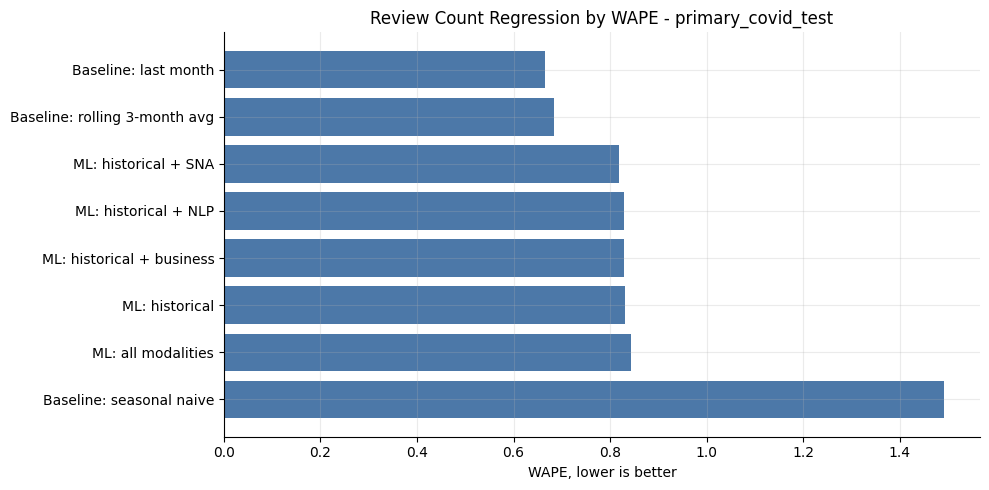

C:\Users\mehdi\OneDrive\Documents\community-forecasting-yelp\outputs\figures\models\review_count_wape_comparison_primary_covid_test.png


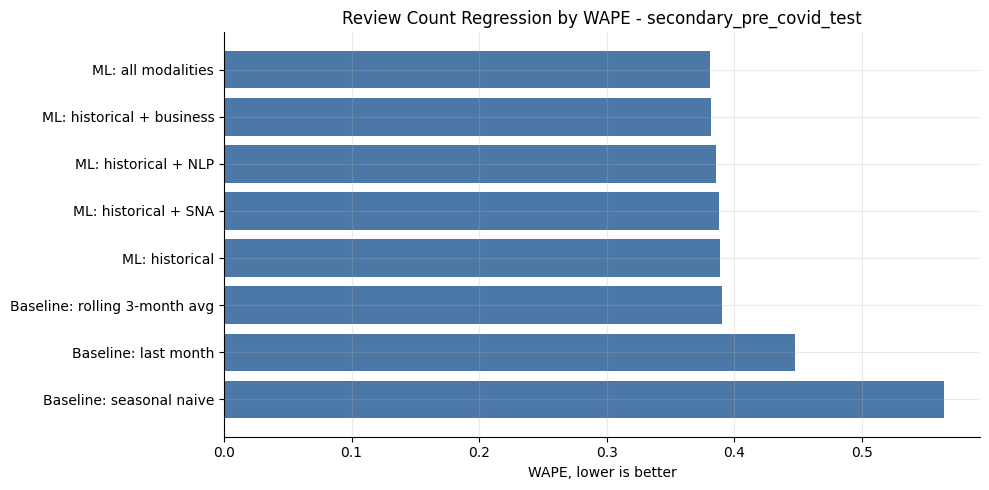

C:\Users\mehdi\OneDrive\Documents\community-forecasting-yelp\outputs\figures\models\review_count_wape_comparison_secondary_pre_covid_test.png


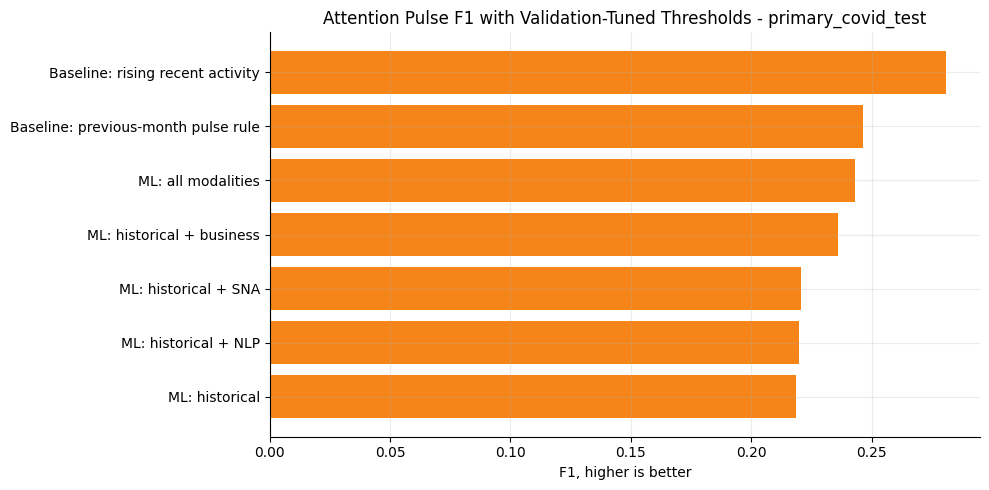

C:\Users\mehdi\OneDrive\Documents\community-forecasting-yelp\outputs\figures\models\attention_pulse_f1_comparison_primary_covid_test.png


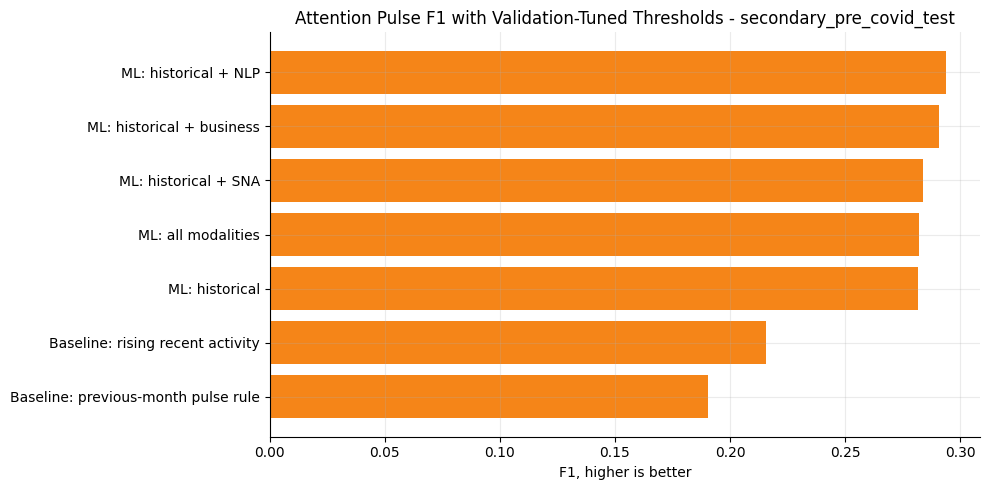

C:\Users\mehdi\OneDrive\Documents\community-forecasting-yelp\outputs\figures\models\attention_pulse_f1_comparison_secondary_pre_covid_test.png


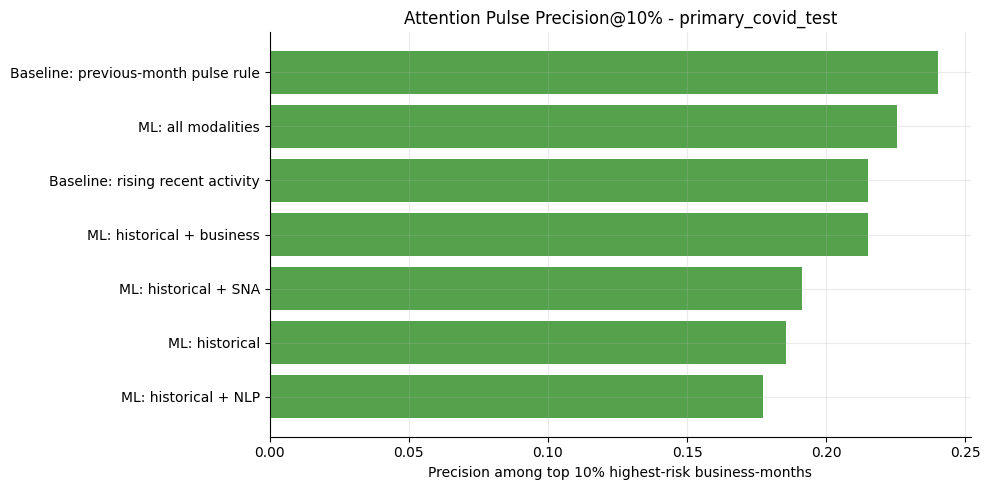

C:\Users\mehdi\OneDrive\Documents\community-forecasting-yelp\outputs\figures\models\attention_pulse_precision_at_10pct_primary_covid_test.png


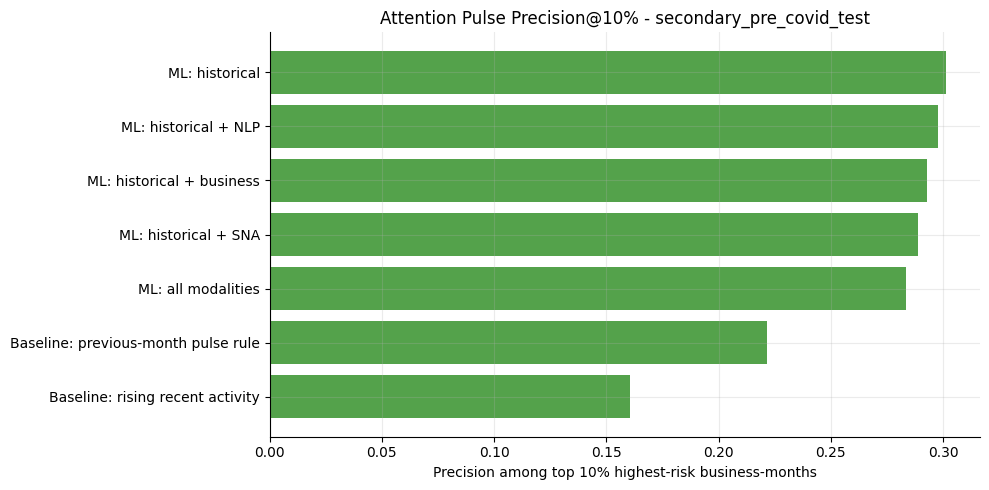

C:\Users\mehdi\OneDrive\Documents\community-forecasting-yelp\outputs\figures\models\attention_pulse_precision_at_10pct_secondary_pre_covid_test.png


In [5]:
for split_name in metrics_df["split"].unique():
    split_metrics = metrics_df[metrics_df["split"] == split_name].sort_values("WAPE")
    fig, ax = plt.subplots(figsize=(10, 5))
    ax.barh(split_metrics["model"], split_metrics["WAPE"], color="#4C78A8")
    ax.invert_yaxis()
    ax.set_title(f"Review Count Regression by WAPE - {split_name}")
    ax.set_xlabel("WAPE, lower is better")
    fig.tight_layout()
    path = FIGURES_DIR / f"review_count_wape_comparison_{split_name}.png"
    fig.savefig(path, dpi=160)
    plt.show()
    plt.close(fig)
    print(path)

for split_name in pulse_metrics_df["split"].unique():
    split_metrics = pulse_metrics_df[pulse_metrics_df["split"] == split_name].sort_values("F1", ascending=False)
    fig, ax = plt.subplots(figsize=(10, 5))
    ax.barh(split_metrics["model"], split_metrics["F1"], color="#F58518")
    ax.invert_yaxis()
    ax.set_title(f"Attention Pulse F1 with Validation-Tuned Thresholds - {split_name}")
    ax.set_xlabel("F1, higher is better")
    fig.tight_layout()
    path = FIGURES_DIR / f"attention_pulse_f1_comparison_{split_name}.png"
    fig.savefig(path, dpi=160)
    plt.show()
    plt.close(fig)
    print(path)

for split_name in pulse_topk_metrics_df["split"].unique():
    split_topk = pulse_topk_metrics_df[
        (pulse_topk_metrics_df["split"] == split_name)
        & (pulse_topk_metrics_df["k_fraction"] == 0.10)
    ].sort_values("precision_at_k", ascending=False)
    fig, ax = plt.subplots(figsize=(10, 5))
    ax.barh(split_topk["model"], split_topk["precision_at_k"], color="#54A24B")
    ax.invert_yaxis()
    ax.set_title(f"Attention Pulse Precision@10% - {split_name}")
    ax.set_xlabel("Precision among top 10% highest-risk business-months")
    fig.tight_layout()
    path = FIGURES_DIR / f"attention_pulse_precision_at_10pct_{split_name}.png"
    fig.savefig(path, dpi=160)
    plt.show()
    plt.close(fig)
    print(path)

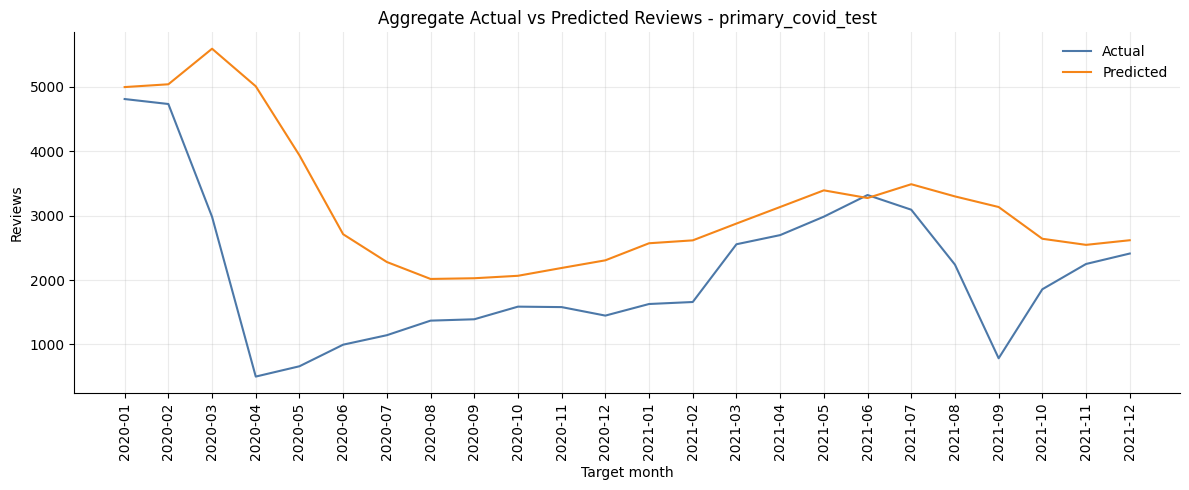

C:\Users\mehdi\OneDrive\Documents\community-forecasting-yelp\outputs\figures\models\review_count_actual_vs_predicted_primary_covid_test.png


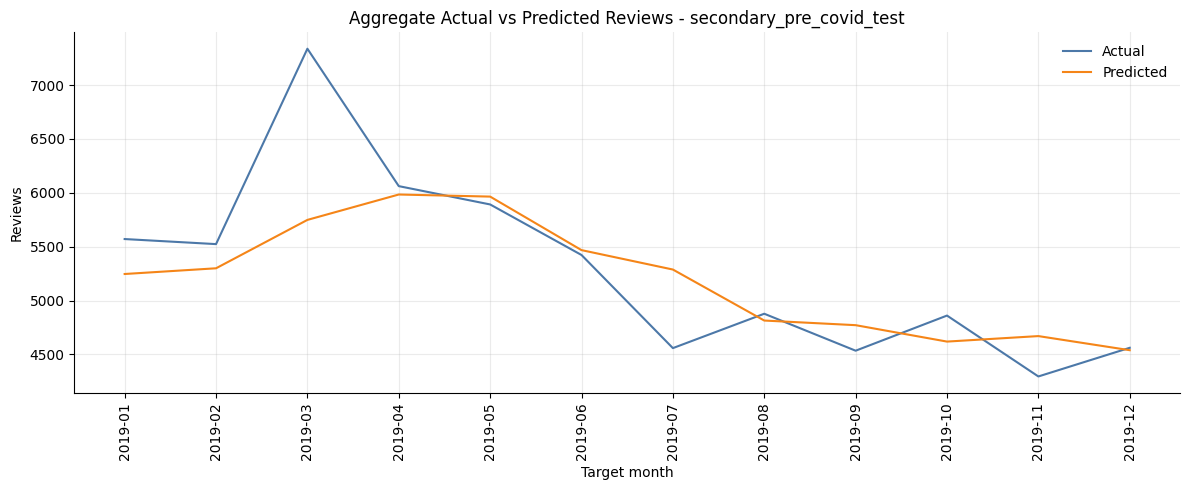

C:\Users\mehdi\OneDrive\Documents\community-forecasting-yelp\outputs\figures\models\review_count_actual_vs_predicted_secondary_pre_covid_test.png


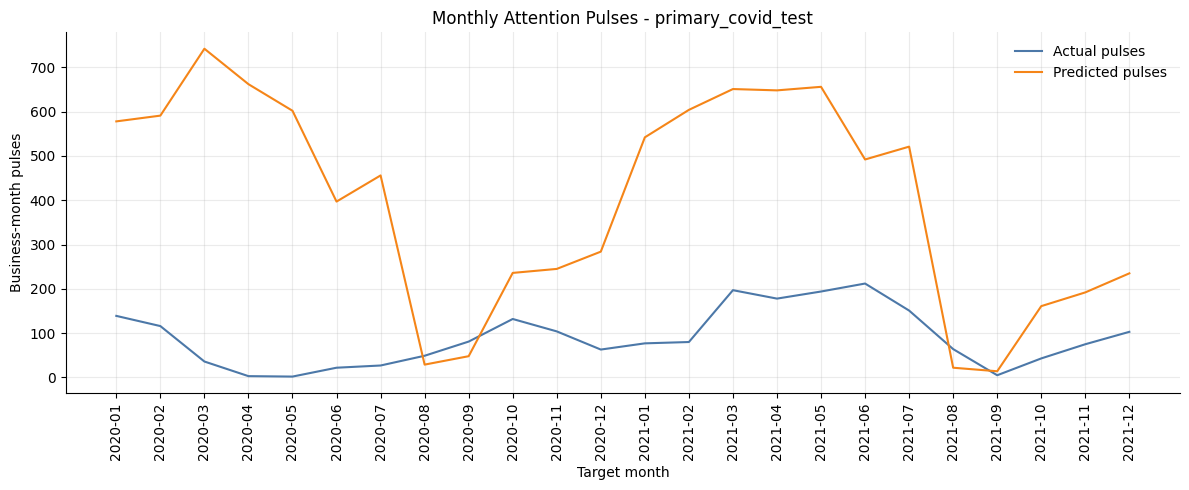

C:\Users\mehdi\OneDrive\Documents\community-forecasting-yelp\outputs\figures\models\attention_pulse_actual_vs_predicted_primary_covid_test.png


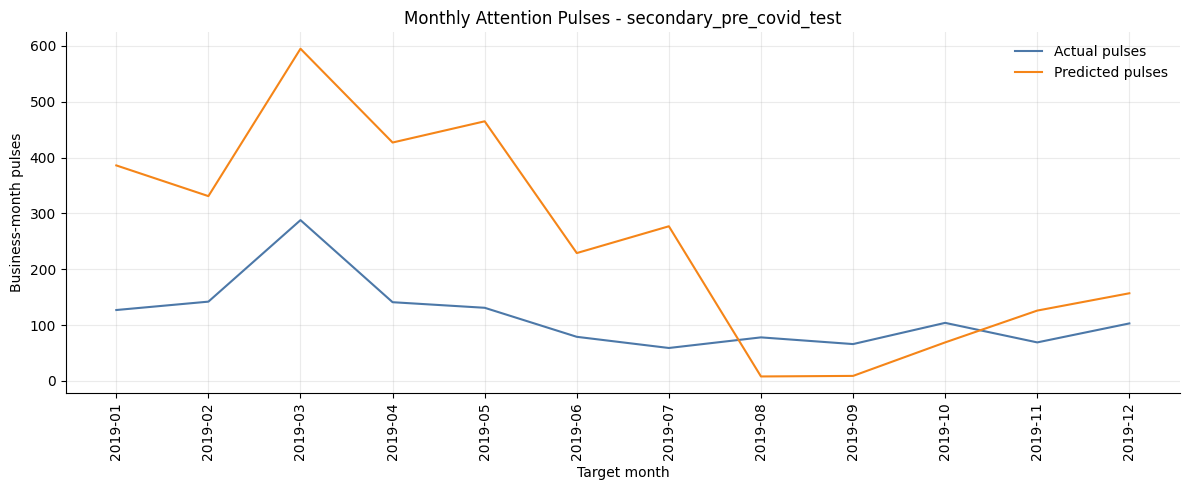

C:\Users\mehdi\OneDrive\Documents\community-forecasting-yelp\outputs\figures\models\attention_pulse_actual_vs_predicted_secondary_pre_covid_test.png


In [6]:
comparison_model = "ML: all modalities"
for split_name in predictions_df["split"].unique():
    plot_df = predictions_df[(predictions_df["split"] == split_name) & (predictions_df["model"] == comparison_model)].copy()
    monthly = plot_df.groupby("target_month_str").agg(actual=("target_next_month_reviews", "sum"), predicted=("prediction", "sum")).reset_index()
    fig, ax = plt.subplots(figsize=(12, 5))
    ax.plot(monthly["target_month_str"], monthly["actual"], label="Actual", color="#4C78A8")
    ax.plot(monthly["target_month_str"], monthly["predicted"], label="Predicted", color="#F58518")
    ax.set_title(f"Aggregate Actual vs Predicted Reviews - {split_name}")
    ax.set_xlabel("Target month")
    ax.set_ylabel("Reviews")
    ax.tick_params(axis="x", rotation=90)
    ax.legend(frameon=False)
    fig.tight_layout()
    path = FIGURES_DIR / f"review_count_actual_vs_predicted_{split_name}.png"
    fig.savefig(path, dpi=160)
    plt.show()
    plt.close(fig)
    print(path)

for split_name in pulse_predictions_df["split"].unique():
    plot_df = pulse_predictions_df[(pulse_predictions_df["split"] == split_name) & (pulse_predictions_df["model"] == comparison_model)].copy()
    monthly = plot_df.groupby("target_month_str").agg(actual_pulses=("attention_pulse", "sum"), predicted_pulses=("prediction", "sum")).reset_index()
    fig, ax = plt.subplots(figsize=(12, 5))
    ax.plot(monthly["target_month_str"], monthly["actual_pulses"], label="Actual pulses", color="#4C78A8")
    ax.plot(monthly["target_month_str"], monthly["predicted_pulses"], label="Predicted pulses", color="#F58518")
    ax.set_title(f"Monthly Attention Pulses - {split_name}")
    ax.set_xlabel("Target month")
    ax.set_ylabel("Business-month pulses")
    ax.tick_params(axis="x", rotation=90)
    ax.legend(frameon=False)
    fig.tight_layout()
    path = FIGURES_DIR / f"attention_pulse_actual_vs_predicted_{split_name}.png"
    fig.savefig(path, dpi=160)
    plt.show()
    plt.close(fig)
    print(path)

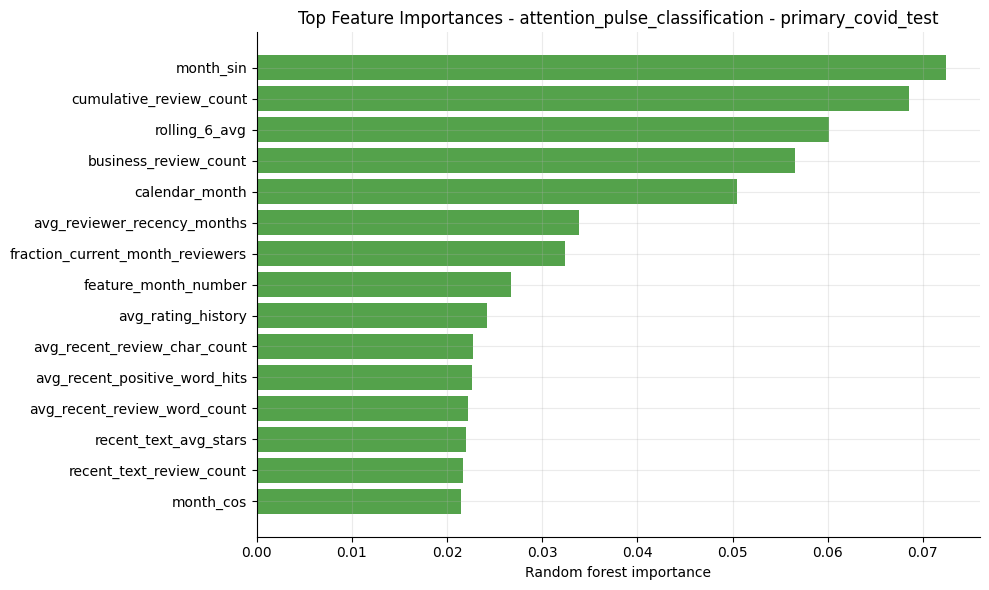

C:\Users\mehdi\OneDrive\Documents\community-forecasting-yelp\outputs\figures\models\attention_pulse_feature_importance_primary_covid_test.png


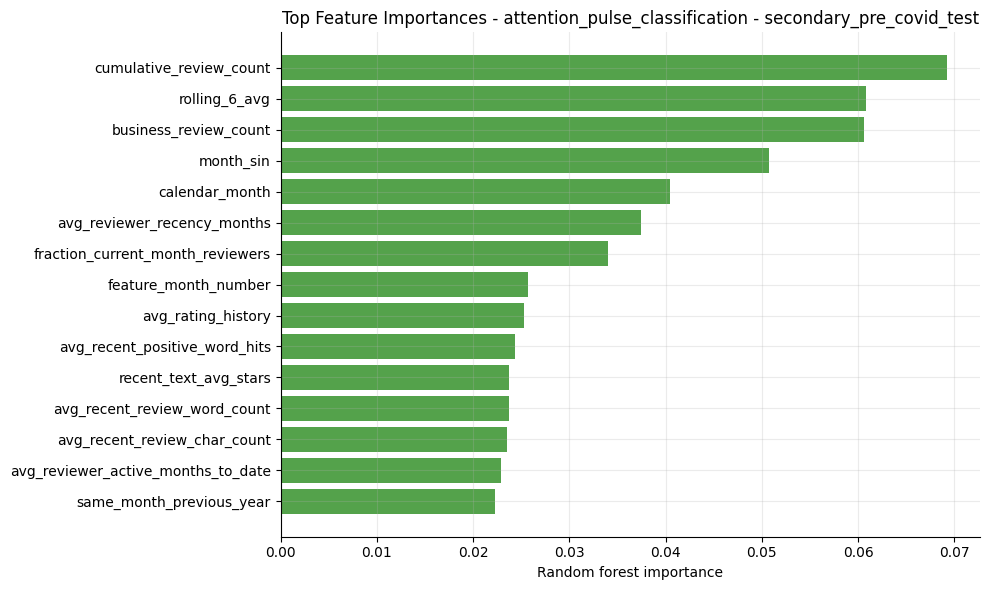

C:\Users\mehdi\OneDrive\Documents\community-forecasting-yelp\outputs\figures\models\attention_pulse_feature_importance_secondary_pre_covid_test.png


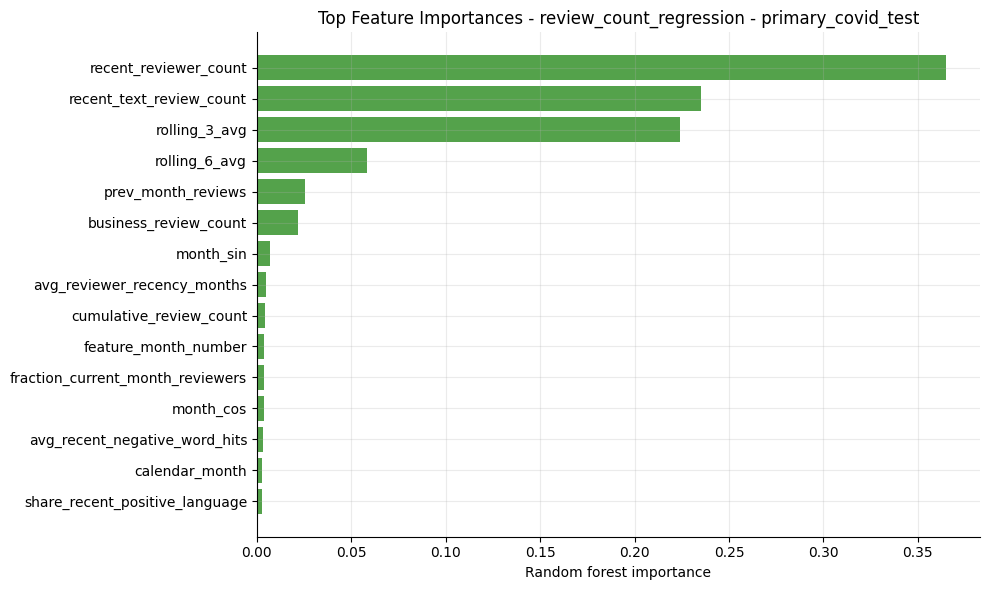

C:\Users\mehdi\OneDrive\Documents\community-forecasting-yelp\outputs\figures\models\review_count_feature_importance_primary_covid_test.png


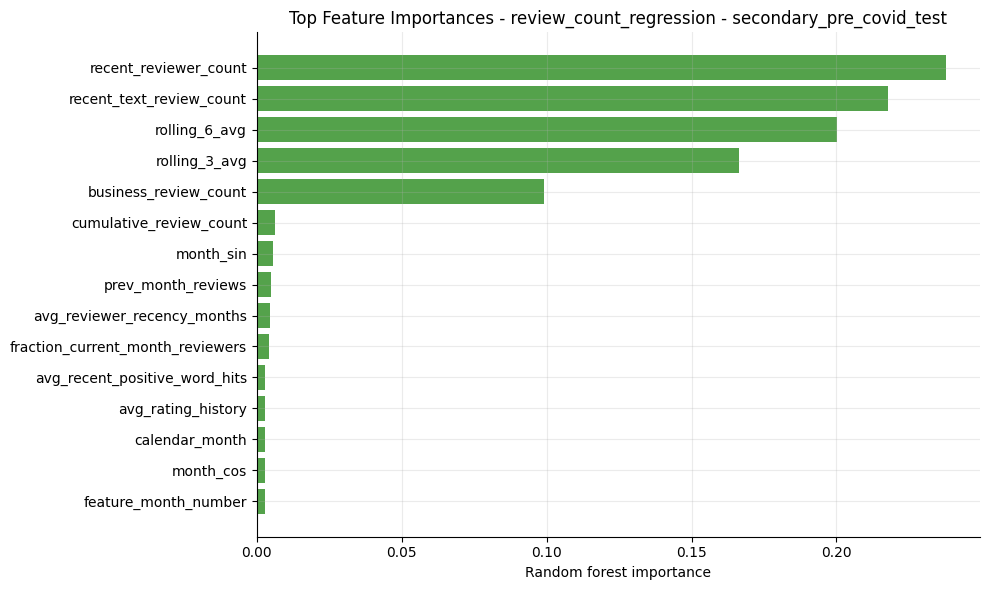

C:\Users\mehdi\OneDrive\Documents\community-forecasting-yelp\outputs\figures\models\review_count_feature_importance_secondary_pre_covid_test.png


,task,split,feature,importance
101,attention_pulse_classification,primary_covid_test,month_sin,0.072394
98,attention_pulse_classification,primary_covid_test,cumulative_review_count,0.068576
96,attention_pulse_classification,primary_covid_test,rolling_6_avg,0.060158
105,attention_pulse_classification,primary_covid_test,business_review_count,0.056540
100,attention_pulse_classification,primary_covid_test,calendar_month,0.050494
131,attention_pulse_classification,primary_covid_test,avg_reviewer_recency_months,0.033880
132,attention_pulse_classification,primary_covid_test,fraction_current_month_reviewers,0.032414
103,attention_pulse_classification,primary_covid_test,feature_month_number,0.026666
99,attention_pulse_classification,primary_covid_test,avg_rating_history,0.024224
134,attention_pulse_classification,primary_covid_test,avg_recent_review_char_count,0.022753


In [7]:
importance_rows = []
for (split_name, model_name), (model, features) in regression_models.items():
    if model_name != "ML: all modalities":
        continue
    for feature, importance in zip(features, model.feature_importances_):
        importance_rows.append({"task": "review_count_regression", "split": split_name, "feature": feature, "importance": importance})
for (split_name, model_name), (model, features, decision_threshold) in pulse_models.items():
    if model_name != "ML: all modalities":
        continue
    for feature, importance in zip(features, model.feature_importances_):
        importance_rows.append({"task": "attention_pulse_classification", "split": split_name, "feature": feature, "importance": importance})

importance_df = pd.DataFrame(importance_rows).sort_values(["task", "split", "importance"], ascending=[True, True, False])

for (task, split_name), group in importance_df.groupby(["task", "split"]):
    top_importance = group.head(15).sort_values("importance")
    fig, ax = plt.subplots(figsize=(10, 6))
    ax.barh(top_importance["feature"], top_importance["importance"], color="#54A24B")
    ax.set_title(f"Top Feature Importances - {task} - {split_name}")
    ax.set_xlabel("Random forest importance")
    fig.tight_layout()
    safe_task = task.replace("_classification", "").replace("_regression", "")
    path = FIGURES_DIR / f"{safe_task}_feature_importance_{split_name}.png"
    fig.savefig(path, dpi=160)
    plt.show()
    plt.close(fig)
    print(path)

importance_df.head(20)

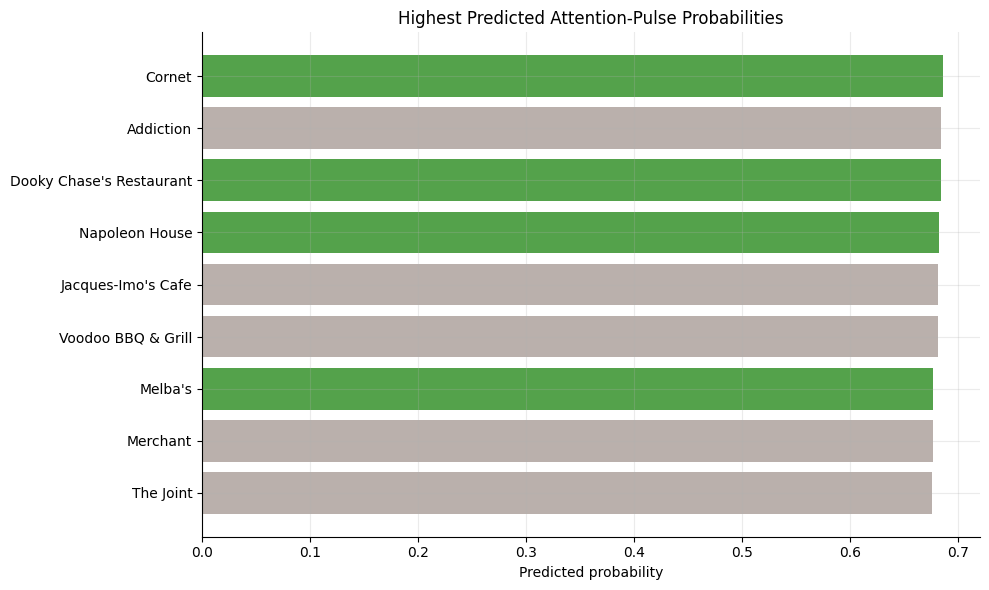

C:\Users\mehdi\OneDrive\Documents\community-forecasting-yelp\outputs\figures\models\attention_pulse_top_predicted_examples.png


,business_id,name,target_month_str,attention_pulse,target_next_month_reviews,pulse_baseline_reviews,pulse_relative_lift,probability
0,-s6EMVPCBrsocFDuiMMqxQ,Cornet,2021-03,1,11.0,3.333333,3.300000,0.686146
1,u0U5IQEQzQauLnP54rMUOA,Addiction,2020-03,0,2.0,2.166667,0.923077,0.684586
2,R9TBf8VqGQ83kvdIxkC9RQ,Dooky Chase's Restaurant,2021-04,1,9.0,3.666667,2.454545,0.684334
3,UeYZgcORV2Veo_BZzdiaTg,Napoleon House,2021-03,1,10.0,4.333333,2.307692,0.682443
4,mhrW9O0O5hXGXGnEYBVoag,Jacques-Imo's Cafe,2021-03,0,3.0,4.333333,0.692308,0.681867
5,UKpPU6X97oPd-dkCK8cheQ,Voodoo BBQ & Grill,2020-04,0,0.0,2.500000,0.000000,0.681260
6,UKpPU6X97oPd-dkCK8cheQ,Voodoo BBQ & Grill,2020-03,0,4.0,2.666667,1.500000,0.678853
7,DnuRO4i1yI5REm5v1pUxWQ,Melba's,2021-03,1,7.0,4.333333,1.615385,0.676710
8,al3Ri6TEqa2rBzjHsn0T_g,Merchant,2020-03,0,2.0,3.666667,0.545455,0.676540
9,UGefDZNmnBztS0eoXWtHyQ,The Joint,2021-03,0,4.0,4.166667,0.960000,0.676052


In [8]:
example_split = "primary_covid_test"
example_model = "ML: all modalities"
examples = (
    pulse_predictions_df[(pulse_predictions_df["split"] == example_split) & (pulse_predictions_df["model"] == example_model)]
    .sort_values("probability", ascending=False)
    .head(10)
    .merge(business_lookup, on="business_id", how="left")
)

fig, ax = plt.subplots(figsize=(10, 6))
labels = examples["name"].fillna(examples["business_id"]).str.slice(0, 35)
colors = np.where(examples["attention_pulse"].eq(1), "#54A24B", "#BAB0AC")
ax.barh(labels[::-1], examples["probability"].values[::-1], color=colors[::-1])
ax.set_title("Highest Predicted Attention-Pulse Probabilities")
ax.set_xlabel("Predicted probability")
fig.tight_layout()
path = FIGURES_DIR / "attention_pulse_top_predicted_examples.png"
fig.savefig(path, dpi=160)
plt.show()
plt.close(fig)
print(path)

examples[["business_id", "name", "target_month_str", "attention_pulse", "target_next_month_reviews", "pulse_baseline_reviews", "pulse_relative_lift", "probability"]]

## Modeling Takeaways

- The corrected evaluation uses train, validation, and test periods for each chronological split.
- Review-count regression is still dominated by recent temporal activity, although ML models now train without seeing the validation year.
- Attention-pulse classifiers use validation-tuned decision thresholds instead of the default `0.5` cutoff.
- Top-k metrics add a retrieval view of the problem: can the model surface the most likely future attention pulses for analyst review?
- SNA and NLP features add interpretable context, but their incremental predictive gain should be judged against both thresholded F1 and top-k precision/recall.